# Exploratory Data Analysis — Fake Job Postings
**Dataset:** [Real or Fake? Fake Job Posting Prediction](https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction) (Kaggle)  
**Goal:** Understand the data distribution, class imbalance, and finding out which features are most predictive for fake job postings before building any model.

---

## 1. Load Dataset & Basic Overview

We start by loading the CSV and checking its shape, columns, class distribution, and null values.  
This tells us two things:
- **How imbalanced** the classes are (critical for metric selection)
- **Which columns have missing values** (missing data is itself a signal here — fake postings tend to omit structured fields)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/fake_job_postings.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass distribution:")
print(df['fraudulent'].value_counts())
print(f"\nFake %: {df['fraudulent'].mean()*100:.2f}%")
print("\nNull counts:")
print(df.isnull().sum())

Shape: (17880, 18)

Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']

Class distribution:
fraudulent
0    17014
1      866
Name: count, dtype: int64

Fake %: 4.84%

Null counts:
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


**Key observations:**
- Dataset has **17,880 rows** and **18 columns**
- Only **~4.8% of postings are fake** — this is a significant class imbalance
- Several columns (salary_range, company_profile, requirements, benefits) have many nulls — absence of these fields turns out to be predictive.
- This imbalance means **accuracy is a misleading metric**: a model that always predicts "Real" would score ~95% accuracy but catch zero fakes. We'll use **F1-score** instead.

## 2. Class Distribution

Visualizing the imbalance between real and fake postings.

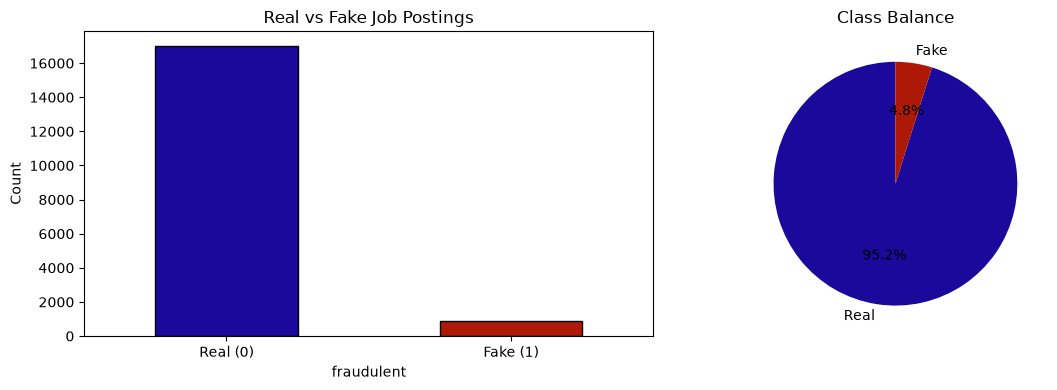

Saved: class_distribution.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
df['fraudulent'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=["#1a099a", "#ad1807"],
    edgecolor='black'
)
axes[0].set_title('Real vs Fake Job Postings')
axes[0].set_xticklabels(['Real (0)', 'Fake (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Pie chart
df['fraudulent'].value_counts().plot(
    kind='pie', ax=axes[1],
    labels=['Real', 'Fake'],
    colors=["#1a099a", "#ad1807"],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Class Balance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Saved: class_distribution.png")

The bar and pie charts confirm the ~95/5 split visually.  
This guided our decision to use **SMOTE (Synthetic Minority Oversampling)** in the baseline model to prevent the classifier from being biased toward always predicting "Real".

## 3. Structured Feature Analysis — Absence as a Signal

One of the most important EDA findings: **the *absence* of structured fields (logo, company profile, salary) is a strong predictor of fake postings**, not just the text content.

We compute fake rate (what % of postings are fake) for each feature being present vs. absent.

In [3]:
structured_cols = ['has_company_logo', 'telecommuting', 'salary_range','company_profile', 'requirements', 'benefits']

print("=== Fake Rate by Structured Feature ===\n")

# Salary range
df['has_salary'] = df['salary_range'].notna().astype(int)
print("Has Salary:")
print(df.groupby('has_salary')['fraudulent'].mean().rename({0:'No salary', 1:'Has salary'}))

# Company logo
print("\nHas Company Logo:")
print(df.groupby('has_company_logo')['fraudulent'].mean())

# Company profile
df['has_profile'] = df['company_profile'].notna().astype(int)
print("\nHas Company Profile:")
print(df.groupby('has_profile')['fraudulent'].mean())

=== Fake Rate by Structured Feature ===

Has Salary:
has_salary
No salary     0.042832
Has salary    0.077755
Name: fraudulent, dtype: float64

Has Company Logo:
has_company_logo
0    0.159290
1    0.019902
Name: fraudulent, dtype: float64

Has Company Profile:
has_profile
0    0.177449
1    0.019146
Name: fraudulent, dtype: float64


In [4]:
print("=" * 50)
print("SUMMARY — Fake Rate by Feature Presence")
print("=" * 50)

summary = pd.DataFrame({
    'Feature': [
        'Has Salary Range',
        'Has Company Logo',
        'Has Company Profile',
    ],
    'Fake Rate (Absent)': [
        df[df['has_salary']==0]['fraudulent'].mean(),
        df[df['has_company_logo']==0]['fraudulent'].mean(),
        df[df['has_profile']==0]['fraudulent'].mean(),
    ],
    'Fake Rate (Present)': [
        df[df['has_salary']==1]['fraudulent'].mean(),
        df[df['has_company_logo']==1]['fraudulent'].mean(),
        df[df['has_profile']==1]['fraudulent'].mean(),
    ]
}).round(4)

summary['Signal Strength'] = (
    summary['Fake Rate (Absent)'] - summary['Fake Rate (Present)']
).round(4)

summary = summary.sort_values('Signal Strength', ascending=False)
print(summary.to_string(index=False))

SUMMARY — Fake Rate by Feature Presence
            Feature  Fake Rate (Absent)  Fake Rate (Present)  Signal Strength
Has Company Profile              0.1774               0.0191           0.1583
   Has Company Logo              0.1593               0.0199           0.1394
   Has Salary Range              0.0428               0.0778          -0.0350


**Key finding from the summary table:**

| Feature | Fake Rate (Absent) | Fake Rate (Present) | Signal Strength |
|---|---|---|---|
| Has Company Profile | **17.7%** | 1.9% | **0.158** |
| Has Company Logo | **15.9%** | 2.0% | **0.139** |
| Has Salary Range | 4.3% | 7.8% | -0.035 |

**Interpretation:**
- A posting with **no company profile** is ~9x more likely to be fake (17.7% vs 1.9%)
- A posting with **no company logo** is ~8x more likely to be fake (15.9% vs 2.0%)
- Salary range is a **negative signal** — fake postings sometimes *do* list a salary to appear credible, slightly raising the fake rate when present
- This means our structured features (has_logo, has_profile) should carry significant weight in the model.

### Visualizing Fake Rate: Feature Absent vs Present

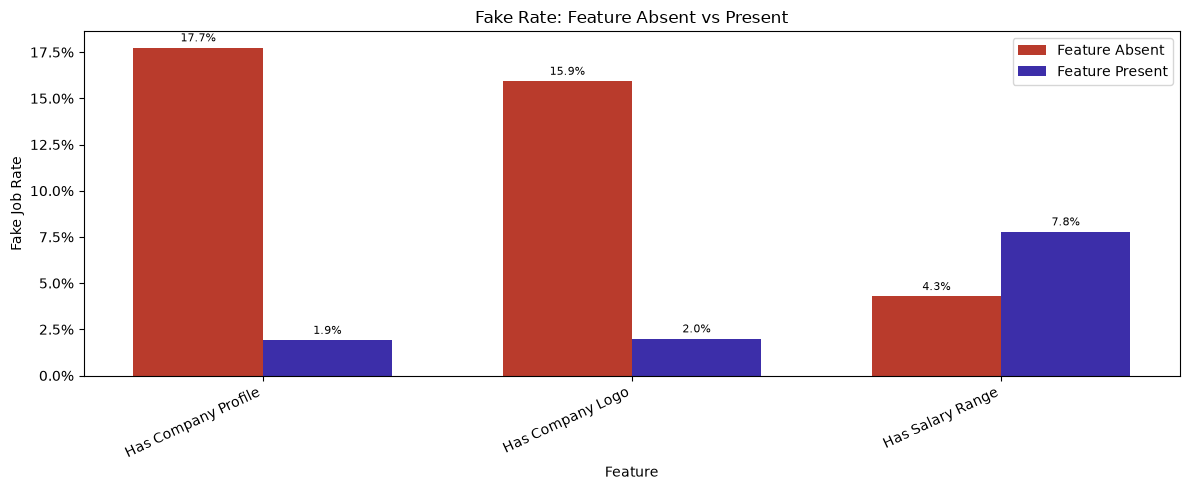

Saved: structured_feature_analysis.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

features   = summary['Feature'].values
absent     = summary['Fake Rate (Absent)'].values
present    = summary['Fake Rate (Present)'].values

x      = np.arange(len(features))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, absent,  width, label='Feature Absent', color='#ad1807', alpha=0.85)
bars2 = ax.bar(x + width/2, present, width, label='Feature Present', color='#1a099a', alpha=0.85)

ax.set_xlabel('Feature')
ax.set_ylabel('Fake Job Rate')
ax.set_title('Fake Rate: Feature Absent vs Present')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=25, ha='right')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('structured_feature_analysis.png', dpi=150)
plt.show()
print("Saved: structured_feature_analysis.png")

## 4. Description Length Analysis

Do fake postings write shorter or longer descriptions? Intuitively, scammers may write vague or short posts, but they might also pad them to appear legitimate.

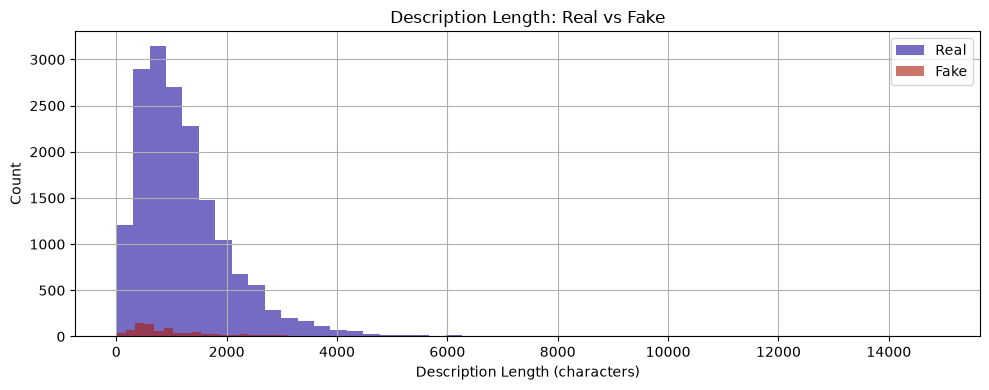

Real avg desc length: 1221.0
Fake avg desc length: 1155.0
=== Top Industries (Fake Jobs) ===
industry
Oil & Energy                           109
Accounting                              57
Hospital & Health Care                  51
Marketing and Advertising               45
Financial Services                      35
Information Technology and Services     32
Telecommunications                      26
Real Estate                             24
Consumer Services                       24
Leisure, Travel & Tourism               21
Name: count, dtype: int64

=== Top Job Functions (Fake Jobs) ===
function
Administrative            119
Engineering               113
Customer Service           67
Sales                      41
Other                      32
Information Technology     32
Accounting/Auditing        29
Finance                    15
Business Development       13
Project Management         10
Name: count, dtype: int64


In [6]:
df['desc_length'] = df['description'].fillna('').apply(len)

fig, ax = plt.subplots(figsize=(10, 4))
df[df['fraudulent']==0]['desc_length'].hist(
    bins=50, alpha=0.6, label='Real', color='#1a099a', ax=ax)
df[df['fraudulent']==1]['desc_length'].hist(
    bins=50, alpha=0.6, label='Fake', color='#ad1807', ax=ax)
ax.set_xlabel('Description Length (characters)')
ax.set_ylabel('Count')
ax.set_title('Description Length: Real vs Fake')
ax.legend()
plt.tight_layout()
plt.savefig('desc_length_distribution.png', dpi=150)
plt.show()

print("Real avg desc length:", df[df['fraudulent']==0]['desc_length'].mean().round(0))
print("Fake avg desc length:", df[df['fraudulent']==1]['desc_length'].mean().round(0))


# ── CELL 6: Top Industries / Job Functions ───────────────────
print("=== Top Industries (Fake Jobs) ===")
print(df[df['fraudulent']==1]['industry'].value_counts().head(10))

print("\n=== Top Job Functions (Fake Jobs) ===")
print(df[df['fraudulent']==1]['function'].value_counts().head(10))

**Findings:**
- Real postings: avg **1,221 characters**
- Fake postings: avg **1,155 characters** — slightly shorter, but the difference is modest (~5.4%)
- The distributions heavily overlap, so description length alone is a **weak standalone signal**
- However, combined with TF-IDF text features, the *content* (not just length) of the description is highly predictive — fake postings use different vocabulary (vague promises, urgency language)

**Top industries for fake postings:** Oil & Energy (109), Accounting (57), Hospital & Health Care (51)  
**Top job functions for fake postings:** Administrative (119), Engineering (113), Customer Service (67)  

Notably, high-volume, low-barrier roles (admin, customer service) and high-prestige sectors (oil & energy, healthcare) both attract scammers.

## 5. Word Cloud — Real vs Fake Descriptions

Visualizing the most frequent words in real vs fake job descriptions gives us an intuition for what the TF-IDF model will learn to separate.

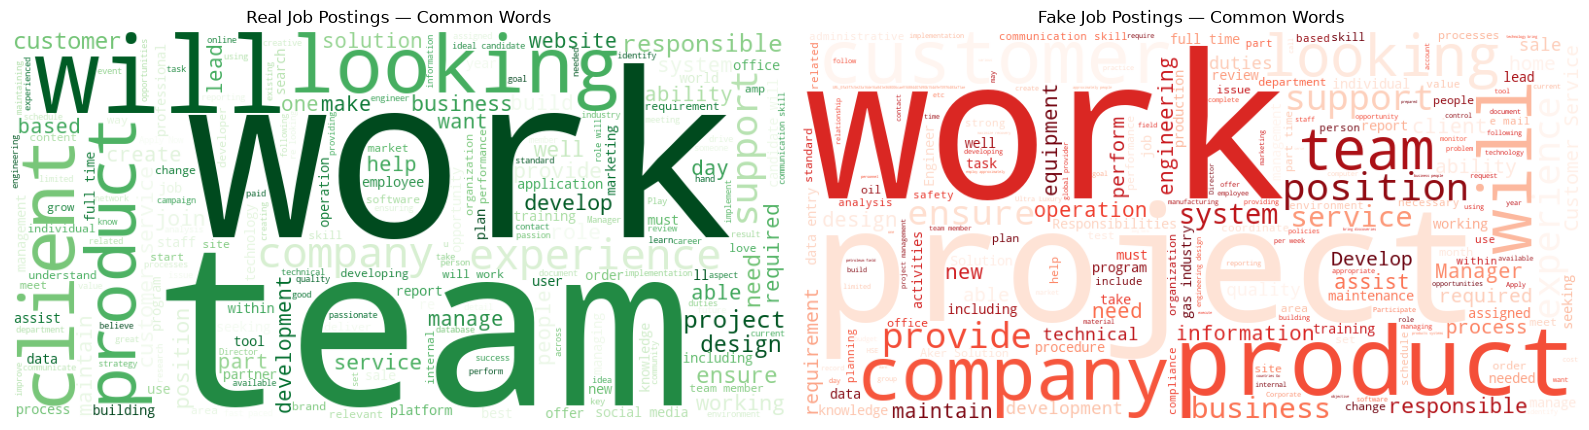

In [7]:
from wordcloud import WordCloud

real_text = ' '.join(df[df['fraudulent']==0]['description'].fillna(''))
fake_text = ' '.join(df[df['fraudulent']==1]['description'].fillna(''))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

WordCloud(width=800, height=400, background_color='white',colormap='Greens').generate(real_text).to_image()
axes[0].imshow(WordCloud(width=800, height=400,background_color='white', colormap='Greens').generate(real_text))
axes[0].set_title('Real Job Postings — Common Words')
axes[0].axis('off')

axes[1].imshow(WordCloud(width=800, height=400,background_color='white', colormap='Reds').generate(fake_text))
axes[1].set_title('Fake Job Postings — Common Words')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordcloud_comparison.png', dpi=150)
plt.show()

**Observations from the word clouds:**
- **Real postings** tend to feature role-specific, technical vocabulary: "experience", "team", "skills", "work", "manage", "develop"
- **Fake postings** lean on vague, high-promise language: "home", "work", "earn", "daily", "training", "paid", "apply"
- These distinct vocabularies are exactly what TF-IDF captures — and why our baseline Logistic Regression achieves strong F1 scores by weighting these discriminating terms highly.